In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


Implementation of a basic pBAD promoter with gIII gene (gene product pIII)

In [15]:
t = sp.symbols('t')
P = sp.Function('P')(t)
A = sp.Function('A')(t)
alpha_base, alpha, Km, n, gamma_P = sp.symbols('alpha_base alpha Km n gamma_P')

dPdt = alpha_base + alpha * (A**n/(A**n + Km)) - gamma_P * P 

P_eq = sp.solve(dPdt, P)[0]
P_eq



(Km*alpha_base + alpha*A(t)**n + alpha_base*A(t)**n)/(gamma_P*(Km + A(t)**n))

In [17]:

P_func = sp.lambdify(
    (A, alpha_base, alpha, Km, n, gamma_P),
    P_eq,
    'numpy'
)

[1.00000000e-02 1.09749877e-02 1.20450354e-02 1.32194115e-02
 1.45082878e-02 1.59228279e-02 1.74752840e-02 1.91791026e-02
 2.10490414e-02 2.31012970e-02 2.53536449e-02 2.78255940e-02
 3.05385551e-02 3.35160265e-02 3.67837977e-02 4.03701726e-02
 4.43062146e-02 4.86260158e-02 5.33669923e-02 5.85702082e-02
 6.42807312e-02 7.05480231e-02 7.74263683e-02 8.49753436e-02
 9.32603347e-02 1.02353102e-01 1.12332403e-01 1.23284674e-01
 1.35304777e-01 1.48496826e-01 1.62975083e-01 1.78864953e-01
 1.96304065e-01 2.15443469e-01 2.36448941e-01 2.59502421e-01
 2.84803587e-01 3.12571585e-01 3.43046929e-01 3.76493581e-01
 4.13201240e-01 4.53487851e-01 4.97702356e-01 5.46227722e-01
 5.99484250e-01 6.57933225e-01 7.22080902e-01 7.92482898e-01
 8.69749003e-01 9.54548457e-01 1.04761575e+00 1.14975700e+00
 1.26185688e+00 1.38488637e+00 1.51991108e+00 1.66810054e+00
 1.83073828e+00 2.00923300e+00 2.20513074e+00 2.42012826e+00
 2.65608778e+00 2.91505306e+00 3.19926714e+00 3.51119173e+00
 3.85352859e+00 4.229242

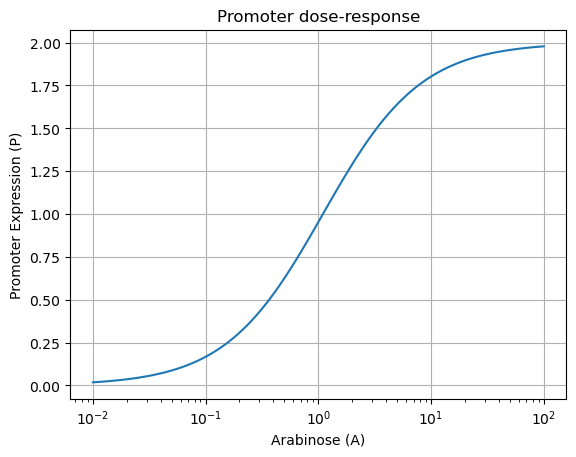

In [31]:
alpha_base = 0
alpha = 1
Km = 1.1
n = 1
gamma_P = 0.5
A_vals = np.logspace(-2, 2, 100)
P_vals = P_func(A_vals, alpha_base, alpha, Km, n, gamma_P)
print(A_vals)
print(P_vals)

plt.plot(A_vals, P_vals)
plt.xlabel("Arabinose (A)")
plt.xscale("log")
plt.ylabel("Promoter Expression (P)")
plt.title("Promoter dose-response")
plt.grid(True)
plt.show()

More complex system that includes transport of arabinose, binding of arabinose, transcription, translation dynamics
$$A_{in} = \text{intracellular arabinose}$$
$$C_A = \text{arabinose-bound AraC}$$
$$P_r = \text{repressed promoter fraction}$$
$$P_a = \text{activated promoter fraction}$$
$$M_{arab} = \text{mRNA}$$
$$pIII = \text{pIII}$$